<h3> SciPython/Practical_classes_5

Given two features $X_1$ and $X_2$, the task is to find a set of weights $[w_1, w_2, w_0]$ such that the linear decision function:

$g(X_1, X_2) = w_1 X_1 + w_2 X_2 + w_0$

correctly classifies the observations into two classes, i.e.:

- the inequality $g(X_1,X_2)>0$ holds for all observations from one class,
- the inequality $g(X_1,X_2)<0$ holds  for all observations from the other class.

This defines a linear decision boundary used in Support Vector Machines (SVM)

### Exercise1

Given two features $X_1$ and $X_2$ and function $g(X_1,X_2) = 2X_1 - 4X_2+1$ decide which of the following observarions belong to the same groups:
    
1. $X_1 = 1$,  $X_2 = -2$
2. $X_1 = 3$,  $X_2 = 1$
3. $X_1 = -1$, $X_2 = 1$
4. $X_1 = 0$,  $X_2 = 2$
5. $X_1 = 0$,  $X_2 = 0$
    
Interpret the coefficients of the function $g$.

In [1]:
from sklearn import datasets
import numpy as np
from mlxtend.plotting import plot_decision_regions
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import make_blobs 
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline

<h4> SVM - 2 classes

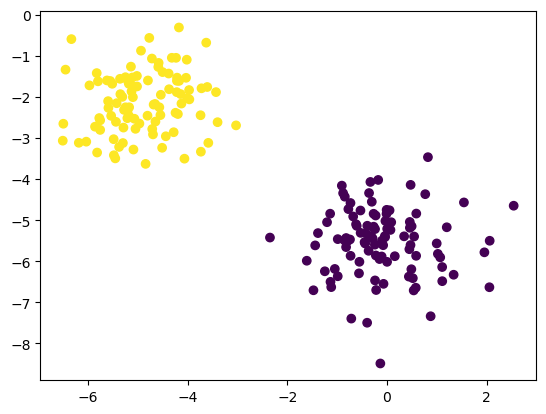

In [2]:
X, y = make_blobs(n_samples=200, random_state=50,
                  n_features=2, centers = 2, 
                  cluster_std = 0.8) 

plt.scatter(X[:, 0], X[:, 1], c = y)
plt.show() 

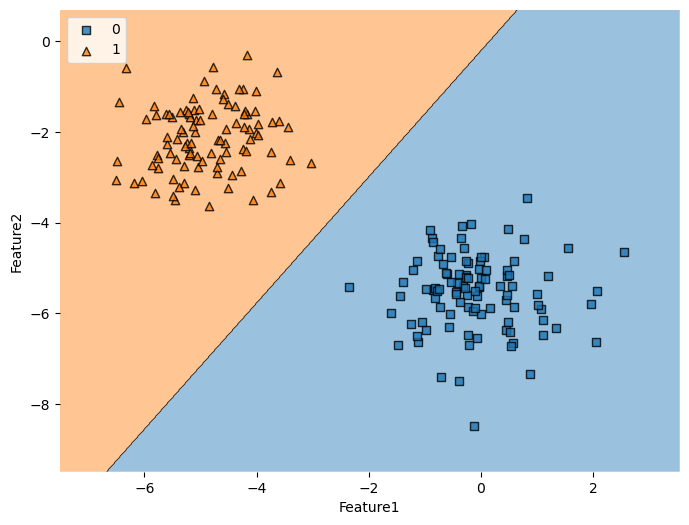

In [3]:
svm = SVC(kernel='linear', C = 0.01, random_state=0) #if data is not balanced, class_weight = "balanced" may help (sometimes :))
svm.fit(X, y);

plt.figure(figsize=(8, 6))
plot_decision_regions(X=X, y=y, clf=svm)
plt.xlabel('Feature1')
plt.ylabel('Feature2')
plt.legend(loc='upper left')
plt.show()

In [4]:
print(svm.coef_, svm.intercept_)

[[-0.38308393  0.27570322]] [0.05866402]


$g(X_1, X_2) = w_1 X_1 + w_2 X_2 + w_0$

In [5]:
svm.score(X, y) #accuracy

1.0

In [6]:
svm.predict([[1, 2],[0,-6], [2,-8]]) #predict label for [X1,X2]

array([1, 0, 0])

<h4> SVM - 3 classes

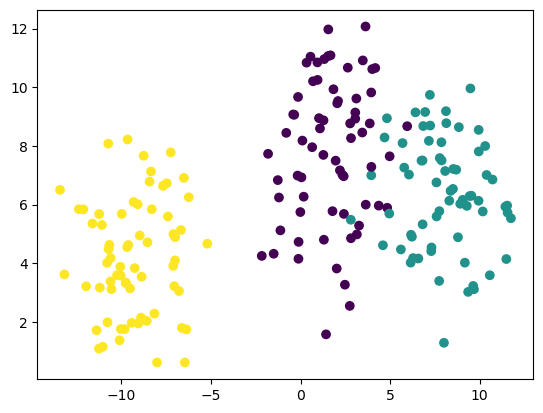

In [7]:
from sklearn.datasets import make_blobs 

X, y = make_blobs(n_samples=200, random_state=20,
                  n_features=2, centers = 3, 
                  cluster_std = 2) 

plt.scatter(X[:, 0], X[:, 1], c = y)
plt.show() 

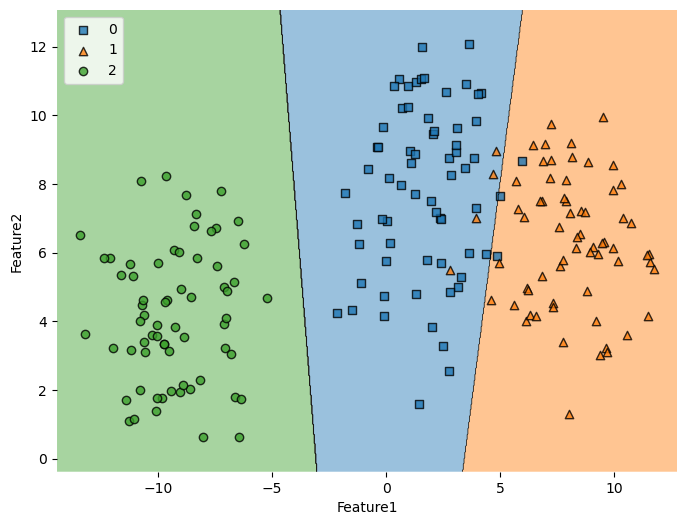

In [8]:
svm = SVC(kernel='linear', C = 0.01, random_state=0)
svm.fit(X, y);

plt.figure(figsize=(8, 6))
plot_decision_regions(X=X, y=y, clf=svm)
plt.xlabel('Feature1')
plt.ylabel('Feature2')
plt.legend(loc='upper left')
plt.show()

In [9]:
svm.score(X, y) #accuracy

0.965

In [10]:
from sklearn.metrics import confusion_matrix
print(confusion_matrix(y, svm.predict(X))) #confusion matrix
print()

[[64  3  0]
 [ 4 63  0]
 [ 0  0 66]]



In [11]:
from sklearn.metrics import classification_report
print(classification_report(y, svm.predict(X)))

              precision    recall  f1-score   support

           0       0.94      0.96      0.95        67
           1       0.95      0.94      0.95        67
           2       1.00      1.00      1.00        66

    accuracy                           0.96       200
   macro avg       0.97      0.97      0.97       200
weighted avg       0.97      0.96      0.96       200



- Precision = 0.94 means that 94% of the predicted positive cases are actually positive.
- Recall = 0.96 means that the model correctly identifies 96% of all real positive cases.

### Exercise2

Consider the Digits dataset. Is the dataset balanced? Divide the data into training and test sets using (8:2 ratio). Build an SVM classifier using the training set. Then, print the confusion matrix and the classification report for the test set.

[ 0.  0.  0.  2. 13.  0.  0.  0.  0.  0.  0.  8. 15.  0.  0.  0.  0.  0.
  5. 16.  5.  2.  0.  0.  0.  0. 15. 12.  1. 16.  4.  0.  0.  4. 16.  2.
  9. 16.  8.  0.  0.  0. 10. 14. 16. 16.  4.  0.  0.  0.  0.  0. 13.  8.
  0.  0.  0.  0.  0.  0. 13.  6.  0.  0.]
4


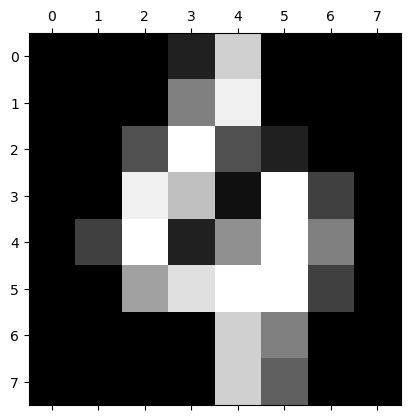

In [12]:
from sklearn.datasets import load_digits

digits = load_digits()

X = digits['data']
y = digits['target']

print(X[100])
print(y[100])

plt.matshow(X[100].reshape(8,8), cmap = "gray")
plt.show()

<h4> Hyperparameters

C is a regularization parameter that controls the trade-off between maximizing the margin and minimizing classification errors. 

- Small C leads to a wider margin and more tolerance to errors, while large C results in a narrower margin and less tolerance to misclassification.

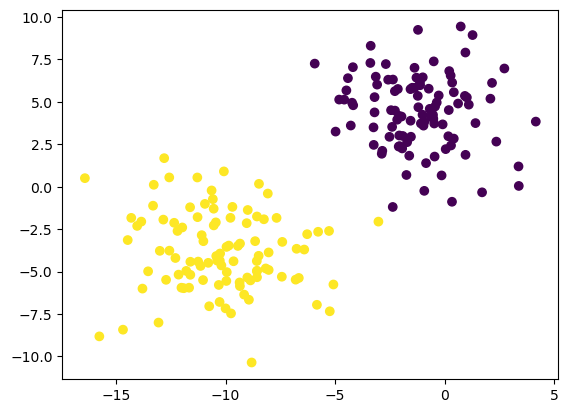

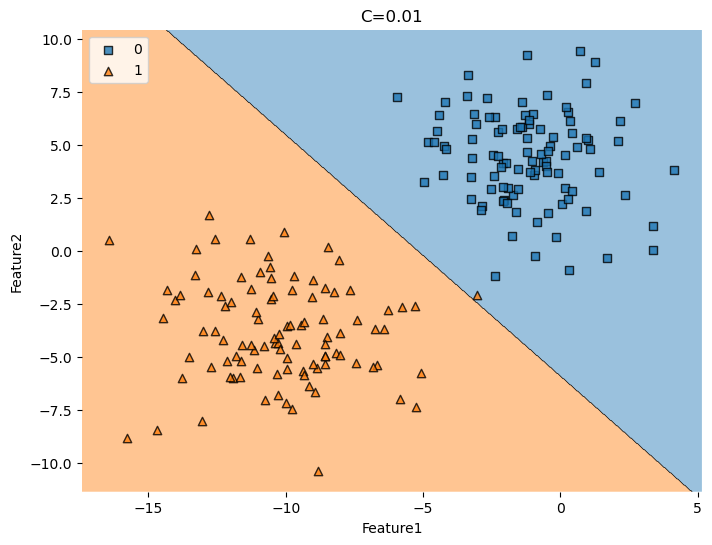

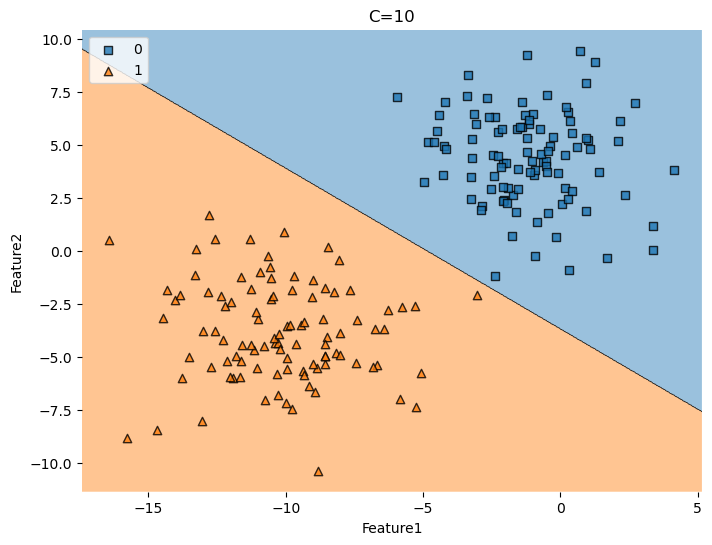

In [13]:
X, y = make_blobs(n_samples=200, random_state=1,
                  n_features=2, centers = 2, 
                  cluster_std = 2.3) 

plt.scatter(X[:, 0], X[:, 1], c = y)
plt.show() 

############
svm = SVC(kernel='linear', C=0.01, random_state=0)
svm.fit(X, y);

plt.figure(figsize=(8, 6))
plot_decision_regions(X=X, y=y, clf=svm)
plt.xlabel('Feature1')
plt.ylabel('Feature2')
plt.legend(loc='upper left')
plt.title("C=0.01")
plt.show()

############
svm = SVC(kernel='linear', C=10, random_state=0)
svm.fit(X, y);

plt.figure(figsize=(8, 6))
plot_decision_regions(X=X, y=y, clf=svm)
plt.xlabel('Feature1')
plt.ylabel('Feature2')
plt.legend(loc='upper left')
plt.title("C=10")
plt.show()

$\gamma$ in the RBF kernel controls the range of influence of a single training example. 

- Small γ results in a smooth decision boundary (low complexity), while large $\gamma$ leads to a highly flexible boundary that can overfit the data..

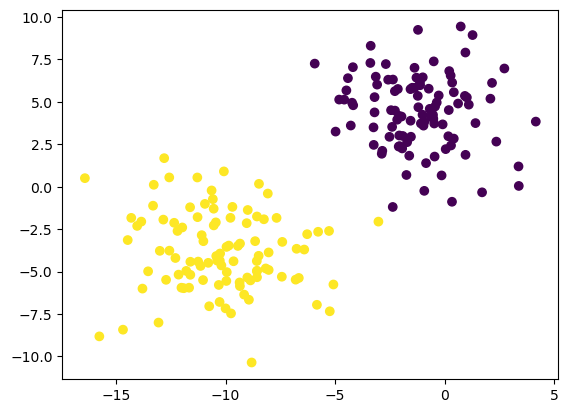

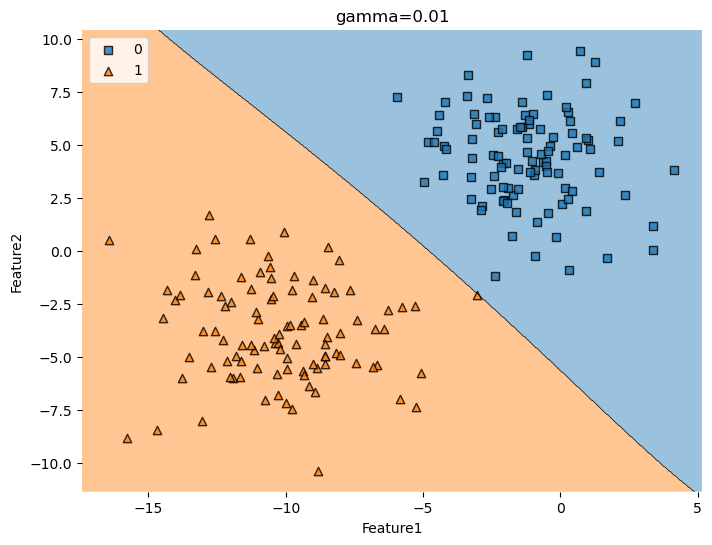

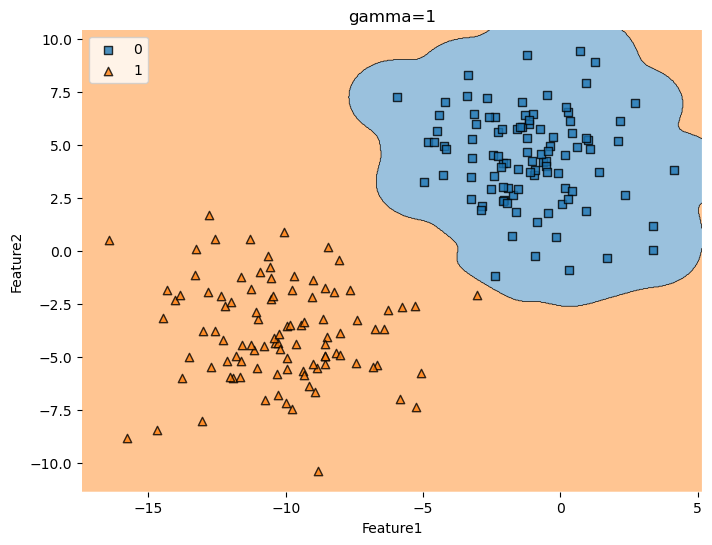

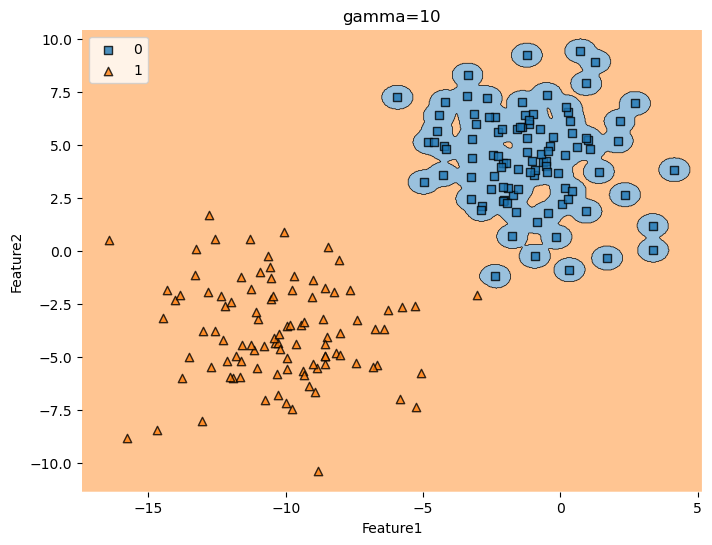

In [14]:
X, y = make_blobs(n_samples=200, random_state=1,
                  n_features=2, centers = 2, 
                  cluster_std = 2.3) 

plt.scatter(X[:, 0], X[:, 1], c = y)
plt.show() 

##########

svm = SVC(kernel='rbf', gamma=0.01, random_state=0)
svm.fit(X, y);


plt.figure(figsize=(8, 6))
plot_decision_regions(X=X, y=y, clf=svm)
plt.xlabel('Feature1')
plt.ylabel('Feature2')
plt.legend(loc='upper left')
plt.title("gamma=0.01")
plt.show()

#############

svm = SVC(kernel='rbf', gamma=1, random_state=0)
svm.fit(X, y);

plt.figure(figsize=(8, 6))
plot_decision_regions(X=X, y=y, clf=svm)
plt.xlabel('Feature1')
plt.ylabel('Feature2')
plt.legend(loc='upper left')
plt.title("gamma=1")
plt.show()

#############

svm = SVC(kernel='rbf', gamma=10, random_state=0)
svm.fit(X, y);

plt.figure(figsize=(8, 6))
plot_decision_regions(X=X, y=y, clf=svm)
plt.xlabel('Feature1')
plt.ylabel('Feature2')
plt.legend(loc='upper left')
plt.title("gamma=10")
plt.show()


<h4> How to adjust hyperparameters? GridSearch

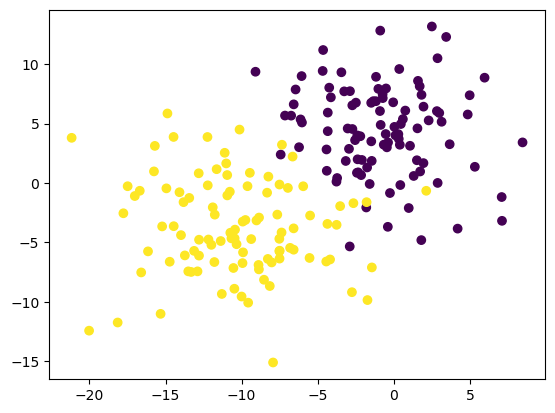

In [25]:
X, y = make_blobs(n_samples=200, random_state=1,
                  n_features=2, centers = 2, 
                  cluster_std = 4) 

plt.scatter(X[:, 0], X[:, 1], c = y)
plt.show() 

In [26]:
svm = SVC(random_state=1)

param_range = [0.0001, 0.001, 0.01, 0.1, 1.0, 10.0, 100.0]

param_grid = [{'C':param_range, 'kernel':['linear']},
              {'C':param_range, 'kernel':['rbf'], 'gamma':param_range}]

gs = GridSearchCV(estimator=svm, param_grid=param_grid, scoring='accuracy', cv=10, n_jobs=-1) #cv-cross validation

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)
gs = gs.fit(X_train, y_train) 

print(gs.best_score_, gs.best_params_, gs.score(X_test, y_test))

0.9571428571428571 {'C': 0.001, 'kernel': 'linear'} 0.9833333333333333


https://archive.ics.uci.edu/dataset/891/cdc+diabetes+health+indicators

### Exercise 3

Consider the diabetes dataset.

- Is the dataset balanced?
- Split the data into training and test sets (8:2).
- Build SVM classifier.
- Tune the hyperparameters using GridSearch.
- Print the confusion matrix and classification report for the test set.

In [17]:
import pandas as pd

df = pd.read_csv("diabetes.csv", sep =",") 

In [18]:
df.head()

,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0


In [19]:
df.shape

(253680, 22)

In [20]:
df.describe()

,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
count,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,...,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000
mean,0.139333,0.429001,0.424121,0.962670,28.382364,0.443169,0.040571,0.094186,0.756544,0.634256,...,0.951053,0.084177,2.511392,3.184772,4.242081,0.168224,0.440342,8.032119,5.050434,6.053875
std,0.346294,0.494934,0.494210,0.189571,6.608694,0.496761,0.197294,0.292087,0.429169,0.481639,...,0.215759,0.277654,1.068477,7.412847,8.717951,0.374066,0.496429,3.054220,0.985774,2.071148
min,0.000000,0.000000,0.000000,0.000000,12.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000
25%,0.000000,0.000000,0.000000,1.000000,24.000000,0.000000,0.000000,0.000000,1.000000,0.000000,...,1.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,6.000000,4.000000,5.000000
50%,0.000000,0.000000,0.000000,1.000000,27.000000,0.000000,0.000000,0.000000,1.000000,1.000000,...,1.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,8.000000,5.000000,7.000000
75%,0.000000,1.000000,1.000000,1.000000,31.000000,1.000000,0.000000,0.000000,1.000000,1.000000,...,1.000000,0.000000,3.000000,2.000000,3.000000,0.000000,1.000000,10.000000,6.000000,8.000000
max,1.000000,1.000000,1.000000,1.000000,98.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,5.000000,30.000000,30.000000,1.000000,1.000000,13.000000,6.000000,8.000000


### Exercise4

Below are nucleotide sequences from human, chimpanzee, and dog. Each sequence belongs to one of seven categories (0–6), which represent functional classes of genes (e.g., kinases, synthases, etc.).

The goal is to build an SVM-based model that predicts the class of a sequence based on its nucleotide sequence. Represent the sequences using k-mer frequencies (e.g., k = 3). Train the classifier using an SVM and evaluate its performance on a test dataset. Tune hyperparameters to improve your model’s performance.

In [28]:
df_train = pd.read_csv("train.csv", sep =",") 
print(df_train.head())

                                            sequence  class species
0  ATGCCATCTCTGCCTCACTCCCACAGGGTAATGTTGGACTCGGTGA...      6   human
1  AATGAACCAAATTCACAATCAAAATTTCCAATTTTTCGGTTTCCTT...      5   human
2  ATGAAGAAATGGAGCAGCACAGACTTGGGGGCAGCTGCGGACCCAC...      5   chimp
3  ATGGCCTCGCGCTGGTGGCGGTGGCGACGCGGCTGCTCCTGGAGGC...      4   chimp
4  ATGGGCTGTGTGCAATGTAAGGATAAAGAAGCAACAAAACTGACGG...      1   human


In [30]:
set(df_train["species"])

{'chimp', 'dog', 'human'}

In [29]:
set(df_train["class"])

{0, 1, 2, 3, 4, 5, 6}

In [31]:
df_test = pd.read_csv("test.csv", sep =",") 
print(df_test.head())

                                            sequence  class species
0  TTTGCTCTTGCTTTTCCTCTAGTTTTATTCCCATTTCCATTCTGGC...      2   chimp
1  ATGAGTTCCCCTGGCACCGAGAGCGCGGGAAAGAGCCTGCAGTACC...      6   chimp
2  NCTTTTGCAGTCTTACAGCTGTACTCTTTCAGCACATTTCCTTTTA...      6   human
3  ATGCACGTGTCACTAGCTGAGGCCCTGGAGGTTCGGGGTGGACCAC...      2   human
4  ATGGTGCACGTAGCCAGGCTGCTGCTGCTGCTCCTCACTTTCTTCC...      2   human


----------

Example: Calculate the distance between the point $P(3,-2)$ and the funtion $f(x) = x^2$.

$f(x) = \sqrt{(x-3)^2+(x^2+2)}$ - distance between $(x,x^2)$ and $(3,-2)$.

$\min_x \sqrt{(x-3)^2+(x^2+2)} = \min_x [(x-3)^2+(x^2+2)] = \min_x [x^2-6x+9+x^4+4x^2+4] = \min_x [x^4+5x^2-6x+13] \approx 11.30$ for $x \approx 0.54$

-----------

### Exercise5 (non-linear functions):
    
- Given the following data, propose an example function $f(x)=ax^2$ that separate the data. Visualize the results. 
    
- Find $a$ that maximize the margin between the data and the function $f(x)=ax^2$. Visualize the results.

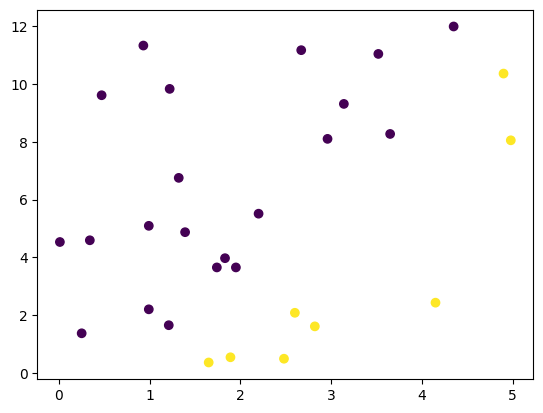

In [179]:
X = np.array([[1.22, 9.83], [2.6, 2.08], [2.82, 1.61], [0.99, 2.2], [1.89, 0.54], [1.74, 3.65], [0.01, 4.53], [1.21, 1.65], [1.65, 0.36], [2.48, 0.49], [2.67, 11.17], [3.52, 11.04], [1.83, 3.97], [4.98, 8.05], [0.25, 1.37], [3.14, 9.31], [2.2, 5.51], [3.65, 8.27], [0.34, 4.59], [0.47, 9.61], [0.99, 5.09], [4.15, 2.43], [4.9, 10.36], [0.93, 11.33], [2.96, 8.1], [1.95, 3.65], [4.35, 11.99], [1.39, 4.87], [1.32, 6.75]])
y = np.array([0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0])

plt.scatter(X[:,0],X[:,1], c = y)
plt.show()

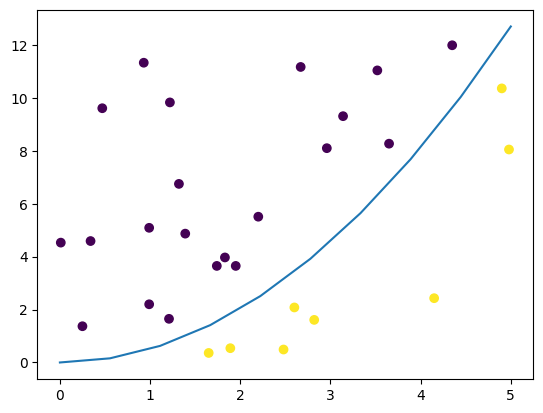

In [198]:
#what we expect?